# Model Interpretation and Explainability

## Feature Importance — A Unified Comparison

### Three Measures and Their Limitations

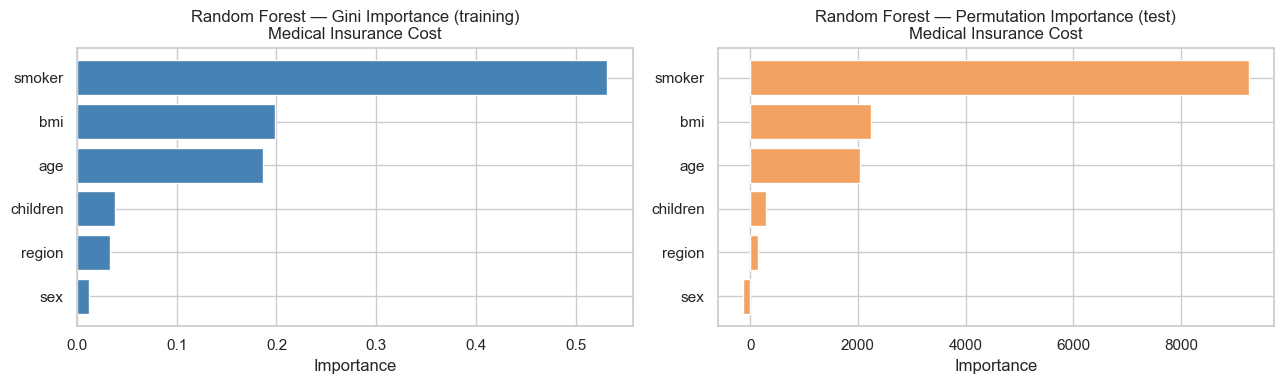

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import (
    GradientBoostingRegressor, GradientBoostingClassifier,
    RandomForestRegressor
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score

# ── Medical Insurance Cost dataset ────────────────────────────────────────
ins_url = (
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets"
    "/master/insurance.csv"
)
df_ins = pd.read_csv(ins_url)
num_cols_ins = ["age", "bmi", "children"]
cat_cols_ins = ["sex", "smoker", "region"]
X_ins = df_ins[num_cols_ins + cat_cols_ins]
y_ins = df_ins["charges"].astype(float)

X_itr, X_ite, y_itr, y_ite = train_test_split(
    X_ins, y_ins, test_size=0.20, random_state=RANDOM_SEED
)

def ins_preprocessor():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols_ins),
        ("cat", cat_pipe, cat_cols_ins)
    ])

def make_ins_pipe(reg):
    return Pipeline([
        ("preprocessor", ins_preprocessor()),
        ("reg",           reg)
    ])

all_feat_names_ins = num_cols_ins + cat_cols_ins

# ── Fit RF for importance comparison ─────────────────────────────────────
rf_ins = make_ins_pipe(
    RandomForestRegressor(
        n_estimators=300, max_features=0.33,
        random_state=RANDOM_SEED, n_jobs=-1
    )
)
rf_ins.fit(X_itr, y_itr)

gini_imp = rf_ins.named_steps["reg"].feature_importances_

X_ite_trans = rf_ins.named_steps["preprocessor"].transform(X_ite)
perm_result = permutation_importance(
    rf_ins.named_steps["reg"],
    X_ite_trans, y_ite,
    n_repeats=20, random_state=RANDOM_SEED,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, imp, title, color in zip(
    axes,
    [gini_imp, perm_result.importances_mean],
    ["Gini Importance (training)", "Permutation Importance (test)"],
    ["steelblue", "#F4A261"]
):
    sorted_idx = np.argsort(imp)
    ax.barh(
        [all_feat_names_ins[i] for i in sorted_idx],
        imp[sorted_idx],
        color=color, edgecolor="white"
    )
    ax.set_xlabel("Importance")
    ax.set_title(f"Random Forest — {title}\nMedical Insurance Cost")

plt.tight_layout()
plt.savefig(FIGURES / "ch17_importance_compare.png", dpi=150, bbox_inches="tight")
plt.show()

## Partial Dependence Plots and Individual Conditional Expectation

### Marginal Effect Visualisation

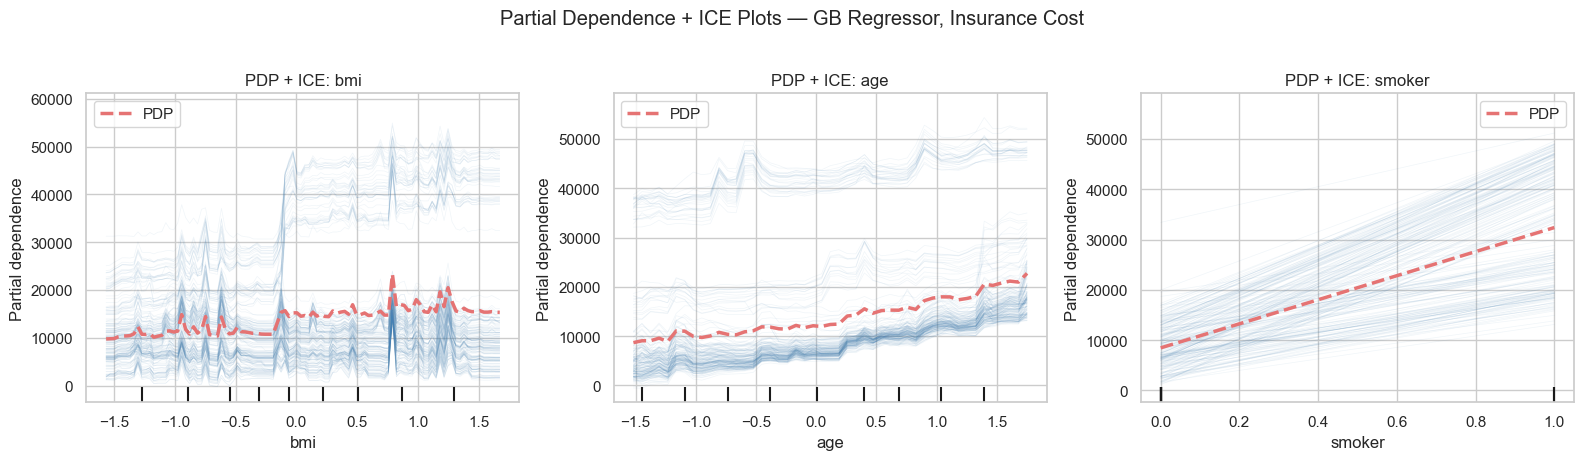

In [2]:
from sklearn.inspection import PartialDependenceDisplay

# ── Fit GB for PDP computation ─────────────────────────────────────────────
gb_ins = make_ins_pipe(
    GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=RANDOM_SEED
    )
)
gb_ins.fit(X_itr, y_itr)

# Extract preprocessed test data
X_itr_processed = pd.DataFrame(
    gb_ins.named_steps["preprocessor"].transform(X_itr),
    columns=all_feat_names_ins
)
X_ite_processed = pd.DataFrame(
    gb_ins.named_steps["preprocessor"].transform(X_ite),
    columns=all_feat_names_ins
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# PDP for bmi, age, smoker
for ax, feat in zip(axes, ["bmi", "age", "smoker"]):
    PartialDependenceDisplay.from_estimator(
        gb_ins.named_steps["reg"],
        X_itr_processed,
        features=[feat],
        kind="both",           # PDP + ICE
        subsample=200,
        random_state=RANDOM_SEED,
        ax=ax,
        ice_lines_kw={"alpha": 0.08, "color": "steelblue"},
        pd_line_kw={"color": "#E57373", "lw": 2.5, "label": "PDP"},
    )
    ax.set_title(f"PDP + ICE: {feat}")
    ax.set_ylabel("Predicted charges ($)")

plt.suptitle("Partial Dependence + ICE Plots — GB Regressor, Insurance Cost",
             y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch17_pdp_ice.png", dpi=150, bbox_inches="tight")
plt.show()

### 2D Partial Dependence: The BMI × Smoker Interaction

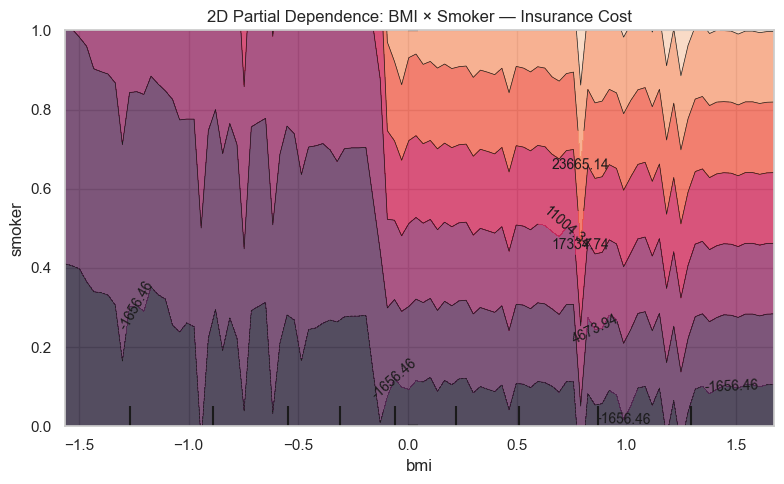

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

PartialDependenceDisplay.from_estimator(
    gb_ins.named_steps["reg"],
    X_itr_processed,
    features=[("bmi", "smoker")],
    kind="average",
    ax=ax,
)
ax.set_title("2D Partial Dependence: BMI × Smoker — Insurance Cost")
plt.tight_layout()
plt.savefig(FIGURES / "ch17_pdp_2d.png", dpi=150, bbox_inches="tight")
plt.show()

## SHAP — Shapley Additive Explanations

### Global SHAP: Summary Plot

In [7]:
import shap
shap.initjs()

# ── TreeSHAP for the GB regressor ─────────────────────────────────────────
explainer_reg = shap.TreeExplainer(gb_ins.named_steps["reg"])
shap_values_reg = explainer_reg(X_ite_processed)

print(f"SHAP values shape : {shap_values_reg.values.shape}")

# Fix for expected_value
base_value = np.asarray(explainer_reg.expected_value).item()   # safely get scalar
print(f"Base value (E[f]) : ${base_value:,.0f}")

print(f"\nMean |SHAP| per feature:")
mean_abs_shap = pd.Series(
    np.abs(shap_values_reg.values).mean(axis=0),
    index=X_ite_processed.columns
).sort_values(ascending=False)

print(mean_abs_shap.to_string())

SHAP values shape : (268, 6)
Base value (E[f]) : $13,303

Mean |SHAP| per feature:
smoker      7808.124134
age         3271.459480
bmi         2281.836945
children     715.575525
region       403.988031
sex          237.303604


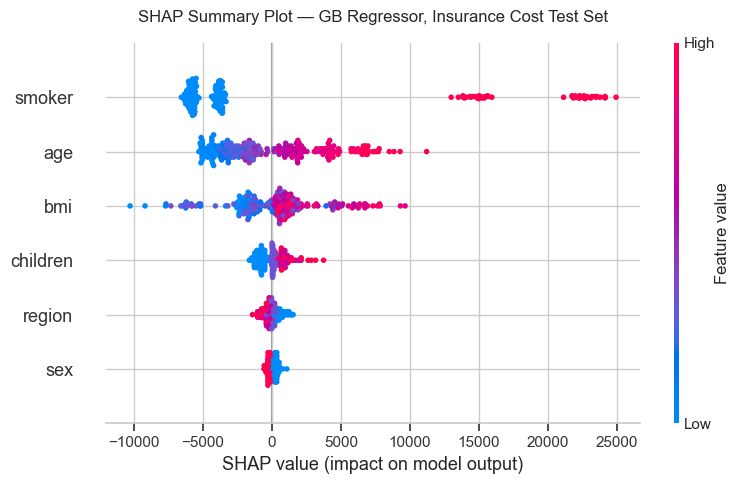

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(
    shap_values_reg.values,
    X_ite_processed,
    show=False,
    plot_size=None
)
plt.title("SHAP Summary Plot — GB Regressor, Insurance Cost Test Set", pad=15)
plt.tight_layout()
plt.savefig(FIGURES / "ch17_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

### Local Explanation: Waterfall Plot for a Single Prediction

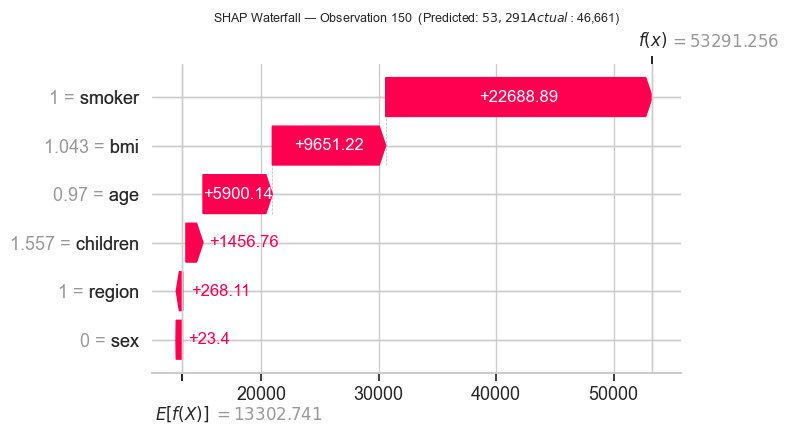

In [9]:
high_pred_idx = np.argmax(gb_ins.predict(X_ite))

fig, ax = plt.subplots(figsize=(8, 5))
shap.plots.waterfall(shap_values_reg[high_pred_idx], max_display=8, show=False)
pred_val   = gb_ins.predict(X_ite)[high_pred_idx]
actual_val = y_ite.iloc[high_pred_idx]
plt.title(
    f"SHAP Waterfall — Observation {high_pred_idx}  "
    f"(Predicted: ${pred_val:,.0f}   Actual: ${actual_val:,.0f})",
    fontsize=9
)
plt.tight_layout()
plt.savefig(FIGURES / "ch17_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

### SHAP Dependence Plot: Exposing Interactions

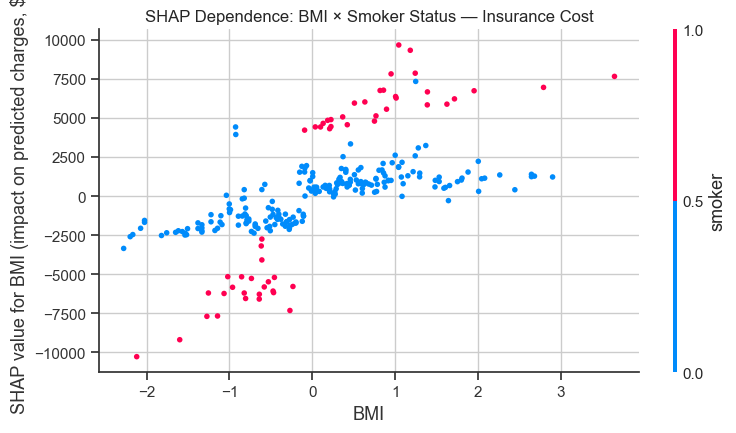

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
shap.dependence_plot(
    "bmi",
    shap_values_reg.values,
    X_ite_processed,
    interaction_index="smoker",
    ax=ax,
    show=False
)
ax.set_title("SHAP Dependence: BMI × Smoker Status — Insurance Cost")
ax.set_xlabel("BMI")
ax.set_ylabel("SHAP value for BMI (impact on predicted charges, $)")
plt.tight_layout()
plt.savefig(FIGURES / "ch17_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()

### SHAP for Classification

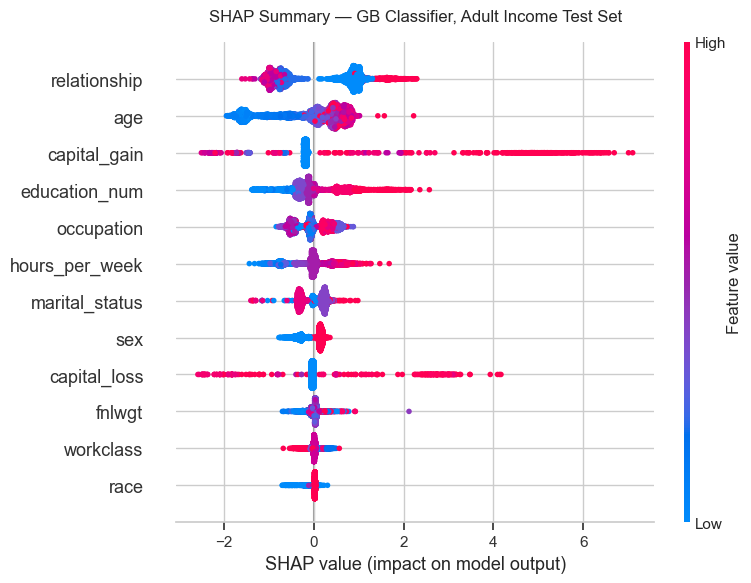

In [11]:
# ── Adult Income dataset ──────────────────────────────────────────────────
adult_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/adult/adult.data"
)
adult_cols = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]
df_adult = pd.read_csv(adult_url, names=adult_cols,
                       na_values=" ?", skipinitialspace=True)
df_adult["income"] = (df_adult["income"].str.strip() == ">50K").astype(int)
df_adult = df_adult.dropna()

cat_cols_adult = [
    "workclass", "education", "marital_status", "occupation",
    "relationship", "race", "sex", "native_country"
]
num_cols_adult = [
    "age", "fnlwgt", "education_num", "capital_gain",
    "capital_loss", "hours_per_week"
]
X_adult = df_adult[num_cols_adult + cat_cols_adult]
y_adult = df_adult["income"]
X_atr, X_ate, y_atr, y_ate = train_test_split(
    X_adult, y_adult,
    test_size=0.20, stratify=y_adult, random_state=RANDOM_SEED
)

def adult_preprocessor():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler())
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1))
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols_adult),
        ("cat", cat_pipe, cat_cols_adult)
    ])

def make_adult_pipe(clf):
    return Pipeline([
        ("preprocessor", adult_preprocessor()),
        ("clf",           clf)
    ])

gb_adult = make_adult_pipe(
    GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1,
        max_depth=4, random_state=RANDOM_SEED
    )
)
gb_adult.fit(X_atr, y_atr)

X_ate_processed = pd.DataFrame(
    gb_adult.named_steps["preprocessor"].transform(X_ate),
    columns=num_cols_adult + cat_cols_adult
)

explainer_cls = shap.TreeExplainer(gb_adult.named_steps["clf"])
shap_values_cls = explainer_cls(X_ate_processed)

fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(
    shap_values_cls.values,
    X_ate_processed,
    max_display=12,
    show=False,
    plot_size=None
)
plt.title("SHAP Summary — GB Classifier, Adult Income Test Set", pad=15)
plt.tight_layout()
plt.savefig(FIGURES / "ch17_shap_cls_summary.png", dpi=150, bbox_inches="tight")
plt.show()

### SHAP Importance vs. Gini vs. Permutation: Unified Comparison

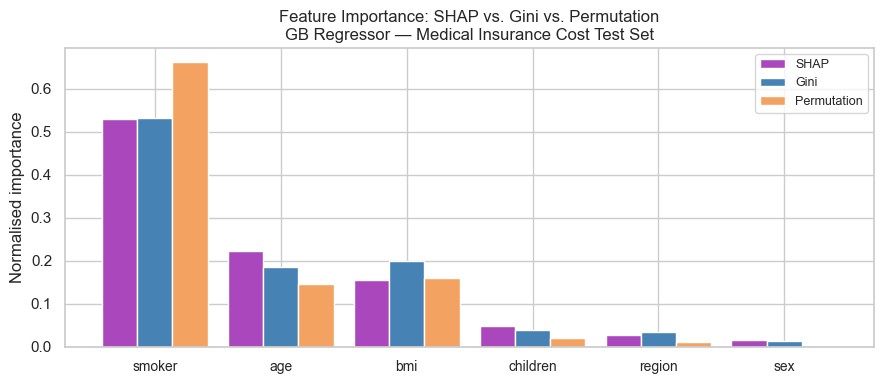

In [12]:
def normalise(s):
    s = s.clip(lower=0)
    return s / s.sum()

shap_imp_reg = pd.Series(
    np.abs(shap_values_reg.values).mean(axis=0),
    index=X_ite_processed.columns
)
gini_series  = pd.Series(gini_imp, index=all_feat_names_ins)
perm_series  = pd.Series(perm_result.importances_mean, index=all_feat_names_ins)

comp_df = pd.DataFrame({
    "SHAP":        normalise(shap_imp_reg),
    "Gini":        normalise(gini_series),
    "Permutation": normalise(perm_series),
}).sort_values("SHAP", ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(all_feat_names_ins))
w = 0.28
ax.bar(x - w, comp_df["SHAP"],        width=w, label="SHAP",
       color="#AB47BC", edgecolor="white")
ax.bar(x,      comp_df["Gini"],        width=w, label="Gini",
       color="steelblue", edgecolor="white")
ax.bar(x + w, comp_df["Permutation"], width=w, label="Permutation",
       color="#F4A261", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(comp_df.index, fontsize=10)
ax.set_ylabel("Normalised importance")
ax.set_title("Feature Importance: SHAP vs. Gini vs. Permutation\n"
             "GB Regressor — Medical Insurance Cost Test Set")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / "ch17_importance_shap_vs_rest.png", dpi=150, bbox_inches="tight")
plt.show()

### Final Evaluation and Explanation Summary

In [13]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("=== Adult Income — Final Model Comparison ===")
print(f"{'Model':25s}  {'Acc':>6}  {'F1':>6}  {'AUC':>6}  {'AP':>6}  {'Brier':>6}")
print("-" * 65)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, brier_score_loss
)

for name, clf in [
    ("Logistic Regression",
     LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_SEED)),
    ("Random Forest",
     RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)),
    ("Gradient Boosting",
     GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=4, random_state=RANDOM_SEED)),
]:
    pipe = make_adult_pipe(clf)
    pipe.fit(X_atr, y_atr)
    y_p = pipe.predict(X_ate)
    proba = pipe.predict_proba(X_ate)[:, 1]
    print(
        f"{name:25s}  "
        f"{accuracy_score(y_ate, y_p):6.4f}  "
        f"{f1_score(y_ate, y_p):6.4f}  "
        f"{roc_auc_score(y_ate, proba):6.4f}  "
        f"{average_precision_score(y_ate, proba):6.4f}  "
        f"{brier_score_loss(y_ate, proba):6.4f}"
    )

=== Adult Income — Final Model Comparison ===
Model                         Acc      F1     AUC      AP   Brier
-----------------------------------------------------------------
Logistic Regression        0.8279  0.5616  0.8608  0.7003  0.1195
Random Forest              0.8635  0.6940  0.9123  0.7944  0.0971
Gradient Boosting          0.8730  0.7139  0.9310  0.8360  0.0864
